In [19]:
import pandas as pd

platform = pd.read_csv("platform_data.csv")
bank = pd.read_csv("bank_data.csv")


In [21]:
platform['date'] = pd.to_datetime(platform['date'])
bank['date'] = pd.to_datetime(bank['date'])


In [23]:
duplicate_ids = bank[bank.duplicated(subset=['transaction_id'], keep=False)]['transaction_id'].unique()

In [25]:
merged = pd.merge(
    platform,
    bank,
    on="transaction_id",
    how="outer",
    suffixes=('_platform', '_bank'),
    indicator=True
)

In [42]:
results = {}
matched = 0
unmatched = 0

In [44]:
for _, row in merged.iterrows():
    tid = row['transaction_id']

    if tid not in results:
        results[tid] = []

    # Missing / Extra
    if row['_merge'] == 'left_only':
        results[tid].append("Missing in bank")

    elif row['_merge'] == 'right_only':
        results[tid].append("Extra in bank")

    else:
        # Amount mismatch
        if row['amount_platform'] != row['amount_bank']:
            results[tid].append(
                f"Amount mismatch ({row['amount_platform']} vs {row['amount_bank']})"
            )

        # Timing mismatch
        if row['date_platform'].month != row['date_bank'].month:
            results[tid].append(
                f"Timing mismatch ({row['date_platform'].date()} vs {row['date_bank'].date()})"
            )

# Add duplicate issues once
for tid in duplicate_ids:
    results.setdefault(tid, []).append("Duplicate in bank")

# Final counts
for tid, issues in results.items():
    if issues:
        unmatched += 1
    else:
        matched += 1


In [46]:
total_transactions = len(results)
accuracy = (matched / total_transactions) * 100

# Output
print("Discrepancy Report:\n")
for tid, issues in results.items():
    if issues:
        print(f"{tid} → {', '.join(set(issues))}")

print("\n--- Summary ---")
print(f"Total Transactions: {total_transactions}")
print(f"Matched Transactions: {matched}")
print(f"Unmatched Transactions: {unmatched}")
print(f"Accuracy: {accuracy:.2f}%")

Discrepancy Report:

T002 → Amount mismatch (500.0 vs 499.0)
T003 → Timing mismatch (2026-03-03 vs 2026-04-01)
T004 → Duplicate in bank
T005 → Missing in bank
T006 → Missing in bank
T007 → Extra in bank

--- Summary ---
Total Transactions: 7
Matched Transactions: 1
Unmatched Transactions: 6
Accuracy: 14.29%


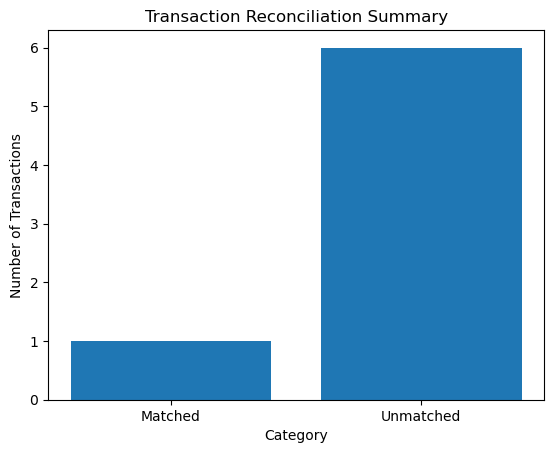

In [48]:
import matplotlib.pyplot as plt

labels = ['Matched', 'Unmatched']
values = [matched, unmatched]

plt.figure()
plt.bar(labels, values)

plt.title("Transaction Reconciliation Summary")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.show()

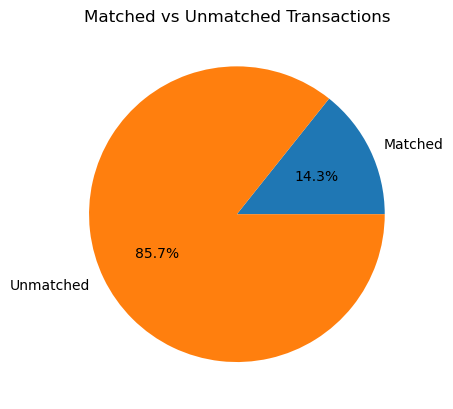

In [50]:
plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Matched vs Unmatched Transactions")

plt.show()